In [3]:
!pip install nltk

In [10]:
import nltk
nltk.download('all')

[nltk_data] Downloading collection 'all'
[nltk_data]    | 
[nltk_data]    | Downloading package abc to /root/nltk_data...
[nltk_data]    |   Package abc is already up-to-date!
[nltk_data]    | Downloading package alpino to /root/nltk_data...
[nltk_data]    |   Package alpino is already up-to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger is already up-
[nltk_data]    |       to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger_eng to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger_eng is already
[nltk_data]    |       up-to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger_ru to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger_ru is already
[nltk_data]    |       up-to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger_r

True

In [11]:
file_path ='/content/Unconfirmed 113114.crdownload'

In [14]:
with open(file_path, 'r') as file:
    text = file.read()

In [15]:
print(text[:1000])

label	review
pos	Stuning even for the non-gamer: This sound track was beautiful! It paints the senery in your mind so well I would recomend it even to people who hate vid. game music! I have played the game Chrono Cross but out of all of the games I have ever played it has the best music! It backs away from crude keyboarding and takes a fresher step with grate guitars and soulful orchestras. It would impress anyone who cares to listen! ^_^
pos	The best soundtrack ever to anything.: I'm reading a lot of reviews saying that this is the best 'game soundtrack' and I figured that I'd write a review to disagree a bit. This in my opinino is Yasunori Mitsuda's ultimate masterpiece. The music is timeless and I'm been listening to it for years now and its beauty simply refuses to fade.The price tag on this is pretty staggering I must say, but if you are going to buy any cd for this much money, this is the only one that I feel would be worth every penny.
pos	"Amazing!: This soundtrack is my favor

In [18]:
import pandas as pd

lines = text.strip().split('\n')

data = []

for line in lines:
    parts = line.strip().split(maxsplit=1)

    if len(parts) == 2:
        label, review = parts
        data.append([label, review])

df = pd.DataFrame(data, columns=['label', 'review'])

df.head()

,label,review
0,label,review
1,pos,Stuning even for the non-gamer: This sound tra...
2,pos,The best soundtrack ever to anything.: I'm rea...
3,pos,"""Amazing!: This soundtrack is my favorite musi..."
4,pos,Excellent Soundtrack: I truly like this soundt...


In [19]:
df.shape

(2593, 2)

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2593 entries, 0 to 2592
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   2593 non-null   object
 1   review  2593 non-null   object
dtypes: object(2)
memory usage: 40.6+ KB


In [21]:
df.describe()

,label,review
count,2593,2593
unique,3,2593
top,neg,Charger works great: The charger works fine as...
freq,1355,1


In [22]:
df.isnull().sum()

,0
label,0
review,0


In [25]:
df.duplicated().sum()

np.int64(0)

In [26]:
df.dtypes

,0
label,object
review,object


In [27]:
df.isnull().sum()

,0
label,0
review,0


In [29]:
df['label'].value_counts()

,count
label,
neg,1355
pos,1237
label,1


In [30]:
df=df[df['label'].isin(['pos','neg'])].reset_index(drop=True)

In [31]:
df['label'].value_counts()

,count
label,
neg,1355
pos,1237


In [32]:
df['review'].str.len().describe()

,review
count,2592.000000
mean,436.446759
std,234.066381
min,102.000000
25%,242.000000
50%,394.000000
75%,582.250000
max,1020.000000


In [33]:
df['review'] = df['review'].str.lower()

In [36]:
import string

df['review']=df['review'].str.translate(
    str.maketrans('','',string.punctuation)
)

In [37]:
df['review'] = df['review'].str.replace(r'\s+', ' ', regex=True).str.strip()

In [38]:
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

df['review'] = df['review'].apply(
    lambda x: ' '.join(word for word in x.split() if word not in stop_words)
)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [39]:
df['tokens'] = df['review'].apply(lambda x: x.split())

In [40]:
['movie', 'good', 'interesting']

['movie', 'good', 'interesting']

In [41]:
df[['review', 'tokens']].head()

,review,tokens
0,stuning even nongamer sound track beautiful pa...,"[stuning, even, nongamer, sound, track, beauti..."
1,best soundtrack ever anything im reading lot r...,"[best, soundtrack, ever, anything, im, reading..."
2,amazing soundtrack favorite music time hands i...,"[amazing, soundtrack, favorite, music, time, h..."
3,excellent soundtrack truly like soundtrack enj...,"[excellent, soundtrack, truly, like, soundtrac..."
4,remember pull jaw floor hearing youve played g...,"[remember, pull, jaw, floor, hearing, youve, p..."


In [42]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()

X = tfidf.fit_transform(df['review'])

In [43]:
X.shape

(2592, 17050)

In [44]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()

X = tfidf.fit_transform(df['review'])

In [45]:
y = df['label']

In [46]:
y.head()

,label
0,pos
1,pos
2,pos
3,pos
4,pos


In [47]:
X = tfidf.fit_transform(df['review'])

In [48]:
y = df['label']

In [50]:
y=df['label']
y.head()

,label
0,pos
1,pos
2,pos
3,pos
4,pos


In [51]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [52]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((2073, 17050), (519, 17050), (2073,), (519,))

In [53]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [54]:
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [55]:
y_pred = model.predict(X_test)

In [56]:
y_pred[:10]

array(['pos', 'neg', 'neg', 'pos', 'pos', 'neg', 'neg', 'pos', 'neg',
       'neg'], dtype=object)

In [57]:
y_pred = model.predict(X_test)

In [58]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, pos_label='pos')
recall = recall_score(y_test, y_pred, pos_label='pos')
f1 = f1_score(y_test, y_pred, pos_label='pos')

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.8458574181117534
Precision: 0.8589743589743589
Recall   : 0.8104838709677419
F1 Score : 0.8340248962655602


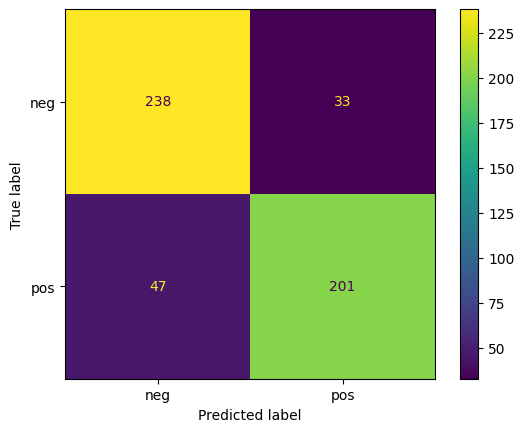

In [59]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred, labels=['neg', 'pos'])

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['neg', 'pos']
)

disp.plot()
plt.show()

In [60]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC()

svm_model.fit(X_train, y_train)

LinearSVC()

In [61]:
y_pred_svm = svm_model.predict(X_test)

In [63]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy_svm = accuracy_score(y_test, y_pred_svm)
precision_svm = precision_score(y_test, y_pred_svm, pos_label='pos')
recall_svm = recall_score(y_test, y_pred_svm, pos_label='pos')
f1_svm = f1_score(y_test, y_pred_svm, pos_label='pos')

print("SVM Accuracy :", accuracy_svm)
print("SVM Precision:", precision_svm)
print("SVM Recall   :", recall_svm)
print("SVM F1 Score :", f1_svm)

SVM Accuracy : 0.8342967244701349
SVM Precision: 0.8292682926829268
SVM Recall   : 0.8225806451612904
SVM F1 Score : 0.8259109311740891


In [64]:
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'SVM'],
    'Accuracy': [accuracy, accuracy_svm],
    'Precision': [precision, precision_svm],
    'Recall': [recall, recall_svm],
    'F1 Score': [f1, f1_svm]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.845857,0.858974,0.810484,0.834025
1,SVM,0.834297,0.829268,0.822581,0.825911


In [65]:
best_model = comparison.loc[comparison['F1 Score'].idxmax()]
best_model

,0
Model,Logistic Regression
Accuracy,0.845857
Precision,0.858974
Recall,0.810484
F1 Score,0.834025


In [66]:
print("Best Model:", best_model['Model'])
print("F1 Score:", best_model['F1 Score'])

Best Model: Logistic Regression
F1 Score: 0.8340248962655602


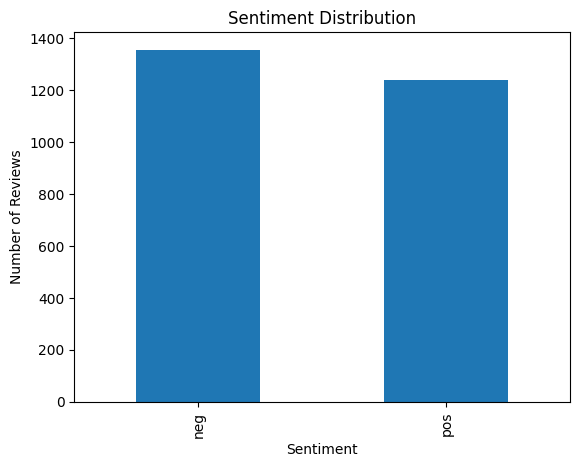

In [67]:
import matplotlib.pyplot as plt

df['label'].value_counts().plot(kind='bar')

plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.show()

In [68]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

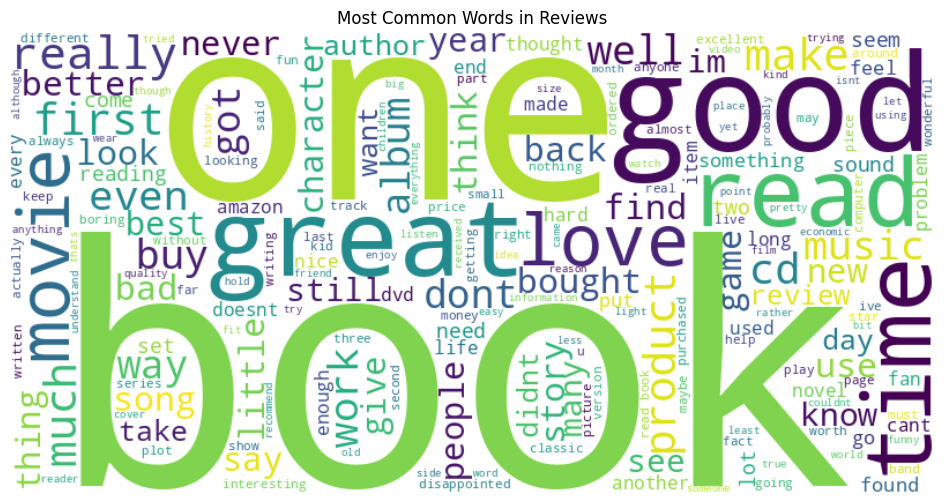

In [69]:
text_all = ' '.join(df['review'])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(text_all)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in Reviews')
plt.show()

In [70]:
from collections import Counter

positive_words = ' '.join(
    df[df['label'] == 'pos']['review']
).split()

positive_counts = Counter(positive_words)

positive_counts.most_common(20)

[('book', 791),
 ('great', 516),
 ('one', 476),
 ('good', 379),
 ('like', 330),
 ('read', 326),
 ('love', 283),
 ('would', 216),
 ('get', 215),
 ('time', 211),
 ('well', 207),
 ('really', 199),
 ('best', 185),
 ('much', 169),
 ('music', 168),
 ('first', 167),
 ('cd', 154),
 ('dont', 152),
 ('also', 144),
 ('album', 144)]

In [71]:
negative_words = ' '.join(
    df[df['label'] == 'neg']['review']
).split()

negative_counts = Counter(negative_words)

negative_counts.most_common(20)

[('book', 927),
 ('one', 555),
 ('like', 433),
 ('would', 373),
 ('read', 332),
 ('dont', 310),
 ('get', 288),
 ('good', 268),
 ('time', 252),
 ('really', 232),
 ('product', 230),
 ('even', 228),
 ('buy', 212),
 ('movie', 210),
 ('first', 207),
 ('much', 201),
 ('money', 197),
 ('bad', 187),
 ('could', 180),
 ('great', 167)]

 NLP techniques were used to classify customer reviews as positive or negative. The text was cleaned and processed, followed by EDA and TF-IDF feature extraction. Logistic Regression and SVM were trained and evaluated using accuracy, precision, recall, F1-score, and a confusion matrix. The better-performing model was selected based on the evaluation results.